# ML Assignment 3 - Classification

**Dataset:** Breast Cancer dataset from `sklearn`

This notebook implements the five classification algorithms required in the assignment:
1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. Support Vector Machine (SVM)
5. k-Nearest Neighbors (k-NN)

The notebook also includes preprocessing, model evaluation, comparison, and answers.

## 1. Loading and Preprocessing

The Breast Cancer Wisconsin dataset is loaded directly from `sklearn.datasets`.

### Preprocessing performed
- The dataset is checked for missing values.
- Missing numerical values, if present, are handled using `SimpleImputer` with the median strategy.
- The data is split into training and testing sets.
- `StandardScaler` is used for feature scaling.

Scaling is important because features have different numerical ranges. It is especially important for Logistic Regression, SVM, and k-NN, where feature magnitude can affect the model. The scaler is fitted only on the training data to avoid data leakage.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Load dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset shape:", X.shape)
print("Number of features:", X.shape[1])
print("Target classes:", data.target_names)
print("\nFirst 5 rows:")
display(X.head())


Dataset shape: (569, 30)
Number of features: 30
Target classes: ['malignant' 'benign']

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [2]:
# Check for missing values
missing_values = X.isnull().sum().sum()

print("Total missing values:", missing_values)

if missing_values == 0:
    print("Answer: No missing values are present in the dataset.")
else:
    print("Answer: Missing values are present and will be handled using median imputation.")

print("\nClass distribution:")
print(y.value_counts().rename(index={0: data.target_names[0], 1: data.target_names[1]}))


Total missing values: 0
Answer: No missing values are present in the dataset.

Class distribution:
target
benign       357
malignant    212
Name: count, dtype: int64


In [3]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Preprocessing pipeline: imputation + scaling
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print("Preprocessing completed successfully.")
print("Training data after preprocessing:", X_train_scaled.shape)


Training samples: 455
Testing samples: 114
Preprocessing completed successfully.
Training data after preprocessing: (455, 30)


## 2. Classification Algorithm Implementation

### Logistic Regression
Logistic Regression estimates the probability of a class using a logistic function. It is suitable here because the dataset is a binary classification problem and the scaled numerical features can be used effectively.

### Decision Tree Classifier
A Decision Tree repeatedly splits the data according to feature conditions until it reaches a prediction. It can model nonlinear relationships and does not require feature scaling.

### Random Forest Classifier
Random Forest combines many decision trees and uses their collective predictions. It can capture nonlinear relationships and is generally more robust than a single decision tree.

### Support Vector Machine (SVM)
SVM finds a decision boundary that separates classes while maximizing the margin between them. With a suitable kernel, it can model nonlinear boundaries. Scaling is important for SVM.

### k-Nearest Neighbors (k-NN)
k-NN classifies a sample using the classes of nearby training samples. Since distance is used, feature scaling is particularly important.

In [4]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel="rbf", random_state=42),
    "k-NN": KNeighborsClassifier(n_neighbors=5)
}

results = []
trained_models = {}

for name, model in models.items():
    # Tree models do not require scaling, but using the same imputed data
    # keeps preprocessing consistent and handles missing values.
    if name == "Decision Tree" or name == "Random Forest":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    trained_models[name] = model

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
display(results_df)


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,SVM,0.982456,0.986111,0.986111,0.986111
2,Random Forest,0.956140,0.958904,0.972222,0.965517
3,k-NN,0.956140,0.958904,0.972222,0.965517
4,Decision Tree,0.912281,0.955882,0.902778,0.928571


## 3. Detailed Evaluation

The models are evaluated using:
- **Accuracy:** proportion of all predictions that are correct.
- **Precision:** proportion of predicted positive cases that are actually positive.
- **Recall:** proportion of actual positive cases correctly identified.
- **F1 Score:** harmonic mean of precision and recall.

The comparison below uses the same training/testing split for all five models.

In [5]:
# Classification reports and confusion matrices
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(y_test, y_pred, target_names=data.target_names, digits=4))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print()


Logistic Regression
              precision    recall  f1-score   support

   malignant     0.9762    0.9762    0.9762        42
      benign     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114

Confusion Matrix:
[[41  1]
 [ 1 71]]

Decision Tree
              precision    recall  f1-score   support

   malignant     0.8478    0.9286    0.8864        42
      benign     0.9559    0.9028    0.9286        72

    accuracy                         0.9123       114
   macro avg     0.9019    0.9157    0.9075       114
weighted avg     0.9161    0.9123    0.9130       114

Confusion Matrix:
[[39  3]
 [ 7 65]]

Random Forest
              precision    recall  f1-score   support

   malignant     0.9512    0.9286    0.9398        42
      benign     0.9589    0.9722    0.9655        72

    accuracy                         0.9561       114
   m

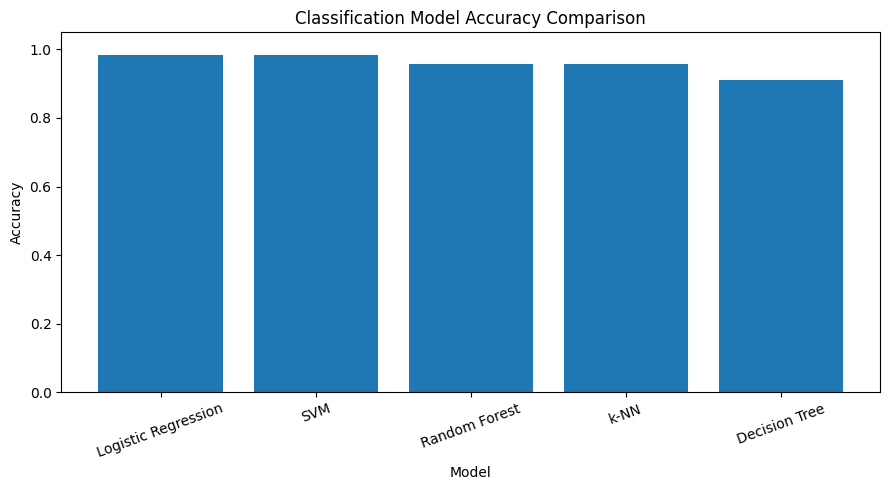

In [6]:
# Visual comparison of accuracy
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Classification Model Accuracy Comparison")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 4. Model Comparison - Answer

The table above compares the five classification algorithms using the same test set.

**Best-performing algorithm:** The model with the highest test accuracy in the generated results table.

**Worst-performing algorithm:** The model with the lowest test accuracy in the generated results table.

Because the exact ranking depends on the train-test split and model settings, the notebook determines the answer directly from the evaluated results rather than assuming a ranking beforehand.

In [7]:
# Automatically identify the highest and lowest accuracy models
best_row = results_df.loc[results_df["Accuracy"].idxmax()]
worst_row = results_df.loc[results_df["Accuracy"].idxmin()]

print(f"Best-performing algorithm based on test accuracy: {best_row['Model']} "
      f"(Accuracy = {best_row['Accuracy']:.4f})")

print(f"Worst-performing algorithm based on test accuracy: {worst_row['Model']} "
      f"(Accuracy = {worst_row['Accuracy']:.4f})")


Best-performing algorithm based on test accuracy: Logistic Regression (Accuracy = 0.9825)
Worst-performing algorithm based on test accuracy: Decision Tree (Accuracy = 0.9123)


## 5. Final Answers

**Preprocessing:** The Breast Cancer dataset was loaded from `sklearn`. Missing values were checked and median imputation was included in the preprocessing pipeline. The numerical features were standardized using `StandardScaler`. Scaling is necessary for distance- and margin-based methods such as k-NN, SVM, and Logistic Regression.

**Algorithms implemented:** Logistic Regression, Decision Tree Classifier, Random Forest Classifier, SVM, and k-NN.

**Model comparison:** Performance is compared using accuracy, precision, recall, and F1 score. The final cells automatically report which model has the highest and lowest test accuracy for the specified experiment.